# Import libs and read data

In [1]:

import warnings
import pandas as pd
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
import os
import pandas as pd

from Strong_hierarchical_lasso.libs_cb_lasso.Helpers_lasso import *




base_path = "../../../KMFM_main_paper/Data/Data_Deoxyfluorination"
filename_Xtrain = "X_train_deoxy.csv"
filename_Xtest = "X_test_deoxy.csv"
filename_ytrain = "y_train_deoxy.csv"
filename_ytest = "y_test_deoxy.csv"

X_train = pd.read_csv(os.path.join(base_path,filename_Xtrain)).to_numpy()
X_test = pd.read_csv(os.path.join(base_path,filename_Xtest)).to_numpy()
y_train = pd.read_csv(os.path.join(base_path,filename_ytrain)).to_numpy().ravel()  
y_test = pd.read_csv(os.path.join(base_path,filename_ytest)).to_numpy().ravel()




# Lasso test set performance 


Trying lambda: 5e-05
Train R² = 0.9977, Val R² = 0.5201

Trying lambda: 0.0001
Train R² = 0.9957, Val R² = 0.6052

Trying lambda: 0.0005
Train R² = 0.9630, Val R² = 0.6907

Trying lambda: 0.001
Train R² = 0.9145, Val R² = 0.6832

Trying lambda: 0.005
Train R² = 0.5812, Val R² = 0.4958

Best λ on validation: 0.0005 (Val R² = 0.6907)

Final Test R² = 0.8521

 Final Test RMSE: 0.11


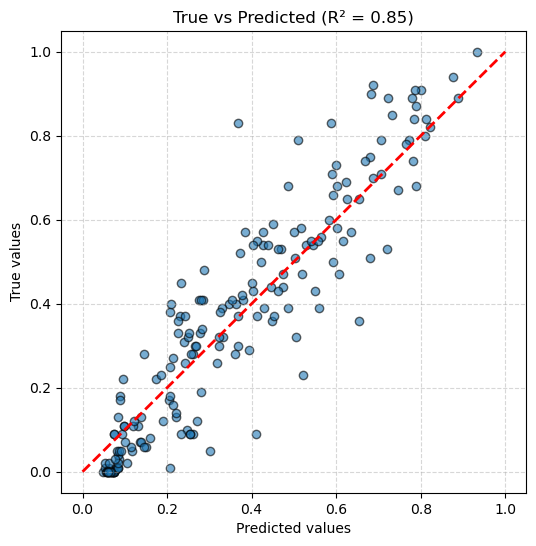

In [2]:
# Do grid search on train val split of train set and see performance on test set
results=grid_search_lasso(
    X_train, X_test, y_train, y_test,
    lambda_grid=[5e-5, 1e-4, 5e-4, 1e-3, 5e-3],
    maxit=10,
    tol=0.5,
    sd_tol=1e-6,
    val_size=0.3,
    random_state=42,
    plot=True
)

#print(results)



# Access best coefs 

In [3]:
best_coefs = results[0]
best_intercept = results[1]
print("lasso coefs: ",best_coefs)
print("intercept: ", best_intercept)


lasso coefs:  [ 7.36684612e+00  3.65587032e+00 -1.09485241e+01  1.14557904e+01
  5.25746834e+00  1.41732847e-01  5.27087787e+00 -8.18291215e-01
 -4.73439158e+00  3.86679825e+00  1.84164237e+00 -8.45822129e+00
 -1.20291284e+00 -5.19419827e+00 -7.82874015e+00  1.73920775e-01
  3.11750796e+00  4.16243098e+00  1.27636955e+00  3.47391558e+00
  1.34159251e+00  2.49826621e+00 -1.13530403e-01 -5.31797162e-01
 -1.31167961e+01  6.71221962e+00  2.01757810e+00 -1.15447280e+01
  5.34072143e+00  1.48062785e+00 -7.43093122e+00 -1.98784602e+00
  2.90004002e-01  5.60626612e-01 -1.80761924e+00 -1.19089773e+00
  2.60197082e-01  6.98265148e-03 -1.82438027e+00 -0.00000000e+00
 -0.00000000e+00  9.07007639e-01  7.65750789e-01  0.00000000e+00
  7.46923576e-02  8.43888365e-01  1.33641948e-01 -0.00000000e+00
  2.85651495e-01  5.20794764e-01  5.83248322e-01  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
  0.00000000e+00  0.00000000e+00 -0.00000000e+00 -4.13306502e+00
 -0.0000000